# Sequential Workout Classification Models

This notebook implements three different sequential models for workout classification using MediaPipe pose landmarks:
1. LSTM Model
2. GRU Model
3. Transformer Model

We'll use 4-second sequences of pose data to classify different types of workouts.

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download the dataset (will use the first path if multiple are returned)
paths = kagglehub.dataset_download("hasyimabdillah/workoutfitness-video")
if isinstance(paths, list):
    path = paths[0]
else:
    path = paths
print("Using dataset path:", path)

# Import our custom modules
import sys
sys.path.append('..')
from mediapipe_handler.sequence_processor import SequenceProcessor

Using dataset path: /Users/yasinetawfeek/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5


## Data Loading and Preprocessing

We'll now:
1. Load the video data
2. Extract pose landmarks using MediaPipe
3. Create 4-second sequences (120 frames at 30fps)
4. Prepare train/validation splits

In [6]:
import pickle
sequence_processor = SequenceProcessor(
    sequence_length=60,
    stride=5,
    target_fps=30)  # 3 seconds at 30fps

try:
    with open('../mediapipe_handler/sequences_labels_tuple.pkl', 'rb') as f:
        sequences, labels = pickle.load(f)
except FileNotFoundError:
    sequences, labels = sequence_processor.process_video_directory(path)

print(f"Total sequences processed: {len(sequences)}")

Total sequences processed: 21416


I0000 00:00:1759787872.047330 27336029 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1759787872.108521 27342825 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1759787872.116197 27342830 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [8]:
unique_labels = sorted(set(labels))  # Sort labels for consistent output
for label in unique_labels:
    count = np.sum(labels == label)
    print(f"{label}: {count} sequences")

barbell biceps curl: 712 sequences
bench press: 782 sequences
chest fly machine: 854 sequences
deadlift: 1016 sequences
decline bench press: 153 sequences
hammer curl: 350 sequences
hip thrust: 882 sequences
incline bench press: 1296 sequences
lat pulldown: 900 sequences
lateral raise: 1470 sequences
leg extension: 741 sequences
leg raises: 606 sequences
plank: 1831 sequences
pull Up: 1012 sequences
push-up: 1276 sequences
romanian deadlift: 1717 sequences
russian twist: 1582 sequences
shoulder press: 694 sequences
squat: 1063 sequences
t bar row: 942 sequences
tricep Pushdown: 579 sequences
tricep dips: 958 sequences


In [9]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    sequences, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
)

# Further split test into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)
print("Number of classes:", len(label_encoder.classes_))

Training set shape: (17132, 60, 36)
Validation set shape: (2142, 60, 36)
Test set shape: (2142, 60, 36)
Number of classes: 22


## LSTM Sequential Model

First, we'll implement an LSTM-based sequential model for workout classification.

In [10]:
# Define LSTM model
def create_lstm_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile LSTM model
lstm_model = create_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=len(label_encoder.classes_)
)

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train LSTM model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 51/536 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.1210 - loss: 2.9962

KeyboardInterrupt: 

## GRU Sequential Model

Now we'll implement a GRU-based model for comparison.

In [ ]:
# Define GRU model
def create_gru_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.GRU(128, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.GRU(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile GRU model
gru_model = create_gru_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=len(label_encoder.classes_)
)

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train GRU model
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.3249 - loss: 2.2066 - val_accuracy: 0.6615 - val_loss: 1.0093
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.6779 - loss: 0.9746 - val_accuracy: 0.8086 - val_loss: 0.6135
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.7842 - loss: 0.6839 - val_accuracy: 0.8613 - val_loss: 0.4474
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.8497 - loss: 0.4776 - val_accuracy: 0.8852 - val_loss: 0.3530
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.8865 - loss: 0.3653 - val_accuracy: 0.8964 - val_loss: 0.3341
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8981 - loss: 0.3274 - val_accuracy: 0.9272 - val_loss: 0.2306
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.9163 - loss: 0.2630 - val_accuracy: 0.9360 - val_loss: 0.1912
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.9316 - loss: 0

## Transformer Sequential Model

Finally, we'll implement a Transformer-based model using self-attention mechanisms.

In [ ]:
# Transformer building blocks
def positional_encoding(length, depth):
    depth = depth/2
    positions = np.arange(length)[:, np.newaxis]
    depths = np.arange(depth)[np.newaxis, :]/depth
    angle_rates = 1 / (10000**depths)
    angle_rads = positions * angle_rates
    pos_encoding = np.concatenate(
        [np.sin(angle_rads), np.cos(angle_rads)],
        axis=-1)
    return tf.cast(pos_encoding, dtype=tf.float32)

@tf.keras.utils.register_keras_serializable()
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Define Transformer model
def create_transformer_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Add positional encoding
    pos_encoding = positional_encoding(input_shape[0], input_shape[1])
    x = inputs + pos_encoding
    
    # Transformer blocks
    transformer_block1 = TransformerBlock(input_shape[1], 8, 32)
    transformer_block2 = TransformerBlock(input_shape[1], 8, 32)
    
    x = transformer_block1(x)
    x = transformer_block2(x)
    
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Create and compile Transformer model
transformer_model = create_transformer_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=len(label_encoder.classes_)
)

transformer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Transformer model
transformer_history = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.2850 - loss: 2.4090 - val_accuracy: 0.6018 - val_loss: 1.1535
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.6448 - loss: 1.0899 - val_accuracy: 0.7946 - val_loss: 0.6555
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7506 - loss: 0.7737 - val_accuracy: 0.8450 - val_loss: 0.5038
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.8135 - loss: 0.6047 - val_accuracy: 0.8908 - val_loss: 0.3538
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8472 - loss: 0.4967 - val_accuracy: 0.8936 - val_loss: 0.3363
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8683 - loss: 0.4263 - val_accuracy: 0.9197 - val_loss: 0.2558
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8870 - loss: 0.3814 - val_accuracy: 0.9146 - val_loss: 0.2799
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.8910 - loss: 0

## Model Evaluation and Comparison

Let's evaluate and compare the performance of all three models.

LSTM Test Accuracy: 0.9911
GRU Test Accuracy: 0.9944
Transformer Test Accuracy: 0.9734
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


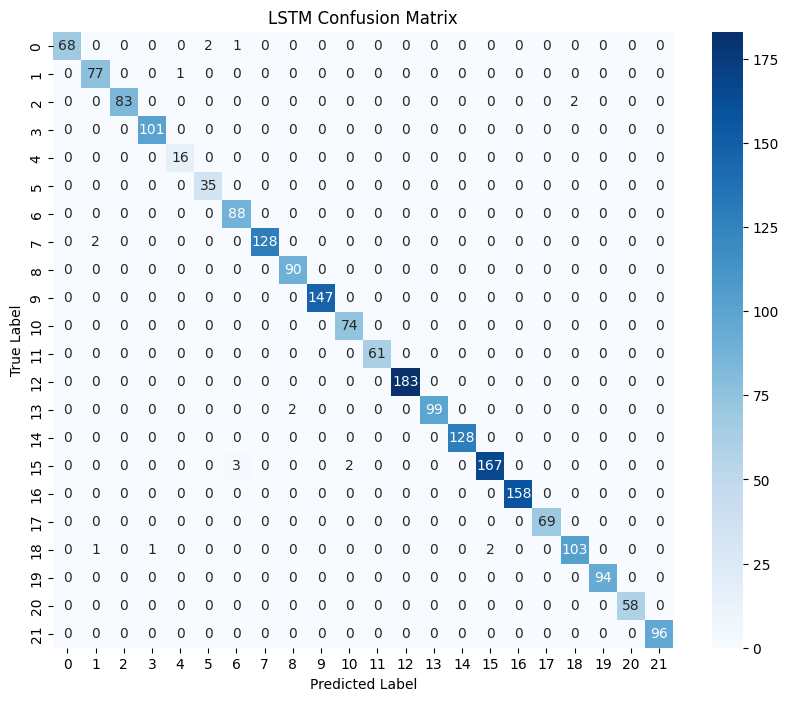

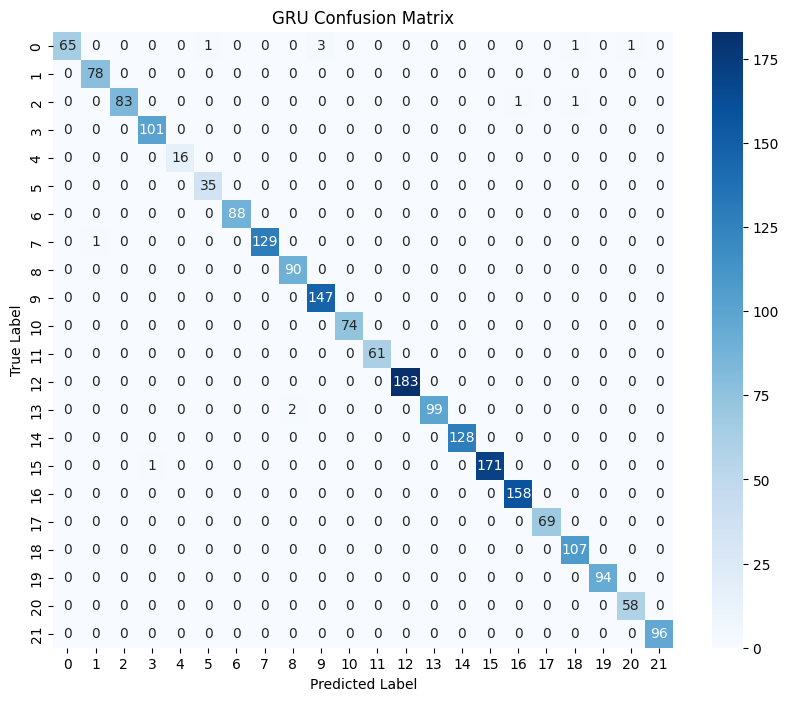

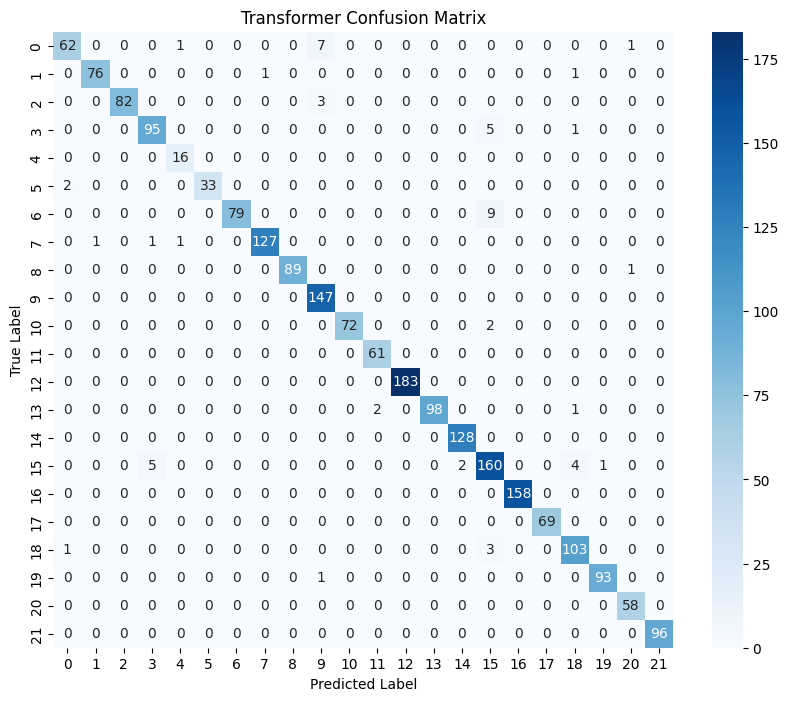


LSTM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        71
           1       0.96      0.99      0.97        78
           2       1.00      0.98      0.99        85
           3       0.99      1.00      1.00       101
           4       0.94      1.00      0.97        16
           5       0.95      1.00      0.97        35
           6       0.96      1.00      0.98        88
           7       1.00      0.98      0.99       130
           8       0.98      1.00      0.99        90
           9       1.00      1.00      1.00       147
          10       0.97      1.00      0.99        74
          11       1.00      1.00      1.00        61
          12       1.00      1.00      1.00       183
          13       1.00      0.98      0.99       101
          14       1.00      1.00      1.00       128
          15       0.99      0.97      0.98       172
          16       1.00      1.00      1.00       15

In [ ]:
# Evaluate models on test set
lstm_scores = lstm_model.evaluate(X_test, y_test, verbose=0)
gru_scores = gru_model.evaluate(X_test, y_test, verbose=0)
transformer_scores = transformer_model.evaluate(X_test, y_test, verbose=0)

# Print test scores
print("LSTM Test Accuracy: {:.4f}".format(lstm_scores[1]))
print("GRU Test Accuracy: {:.4f}".format(gru_scores[1]))
print("Transformer Test Accuracy: {:.4f}".format(transformer_scores[1]))

# Get predictions
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
transformer_pred = transformer_model.predict(X_test)

# Convert predictions to class labels
lstm_pred_classes = np.argmax(lstm_pred, axis=1)
gru_pred_classes = np.argmax(gru_pred, axis=1)
transformer_pred_classes = np.argmax(transformer_pred, axis=1)

# Calculate confusion matrices
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Plot confusion matrices
plot_confusion_matrix(y_test, lstm_pred_classes, 'LSTM')
plot_confusion_matrix(y_test, gru_pred_classes, 'GRU')
plot_confusion_matrix(y_test, transformer_pred_classes, 'Transformer')

# Print classification reports
print("\nLSTM Classification Report:")
print(classification_report(y_test, lstm_pred_classes))

print("\nGRU Classification Report:")
print(classification_report(y_test, gru_pred_classes))

print("\nTransformer Classification Report:")
print(classification_report(y_test, transformer_pred_classes))

## Training History Visualization

Let's visualize the training history of each model to compare their learning curves.

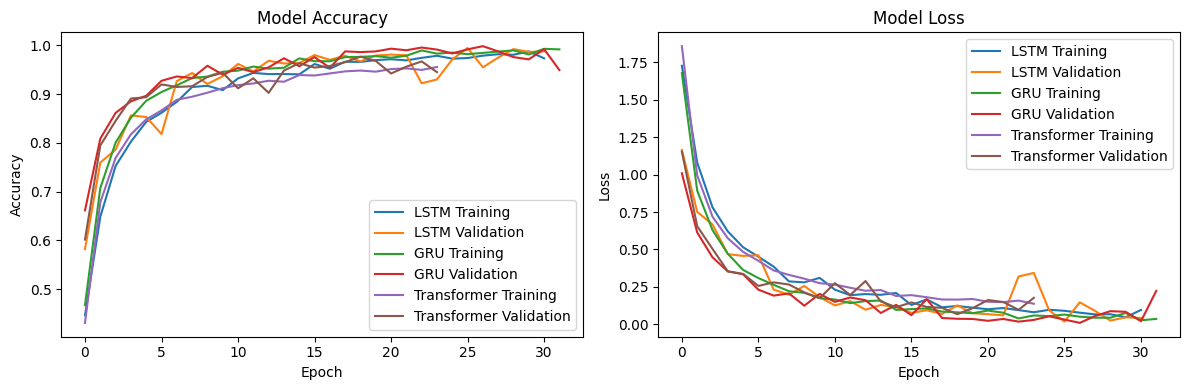

In [ ]:
# Plot training histories
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='LSTM Training')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Validation')
plt.plot(gru_history.history['accuracy'], label='GRU Training')
plt.plot(gru_history.history['val_accuracy'], label='GRU Validation')
plt.plot(transformer_history.history['accuracy'], label='Transformer Training')
plt.plot(transformer_history.history['val_accuracy'], label='Transformer Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='LSTM Training')
plt.plot(lstm_history.history['val_loss'], label='LSTM Validation')
plt.plot(gru_history.history['loss'], label='GRU Training')
plt.plot(gru_history.history['val_loss'], label='GRU Validation')
plt.plot(transformer_history.history['loss'], label='Transformer Training')
plt.plot(transformer_history.history['val_loss'], label='Transformer Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save models
current_directory = os.getcwd()
lstm_model.save(current_directory + '/../../models/workout_classifier/lstm_model.keras')
gru_model.save(current_directory + '/../../models/workout_classifier/gru_model.keras')
transformer_model.save(current_directory + '/../../models/workout_classifier/transformer_model.keras')

# Save label encoder
import pickle
with open(current_directory + '/../../models/workout_classifier/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open(current_directory + '/../mediapipe_handler/sequences_labels_tuple.pkl', 'wb') as f:
    pickle.dump((sequences, labels), f)